In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp

In [ ]:
path_mc = "chunks_MC/"
path_data = "chunks"

mc_chunks = {}

In [10]:
for i in range(5):
    mc_chunks[i] = np.load(f"{path_mc}mc_chunk_{i+1:02d}.npz")

pT_j1: chunk 0 vs 1 → KS=0.000, p=0.524
pT_j1: chunk 0 vs 2 → KS=0.000, p=0.845
pT_j1: chunk 0 vs 3 → KS=0.000, p=0.693
pT_j1: chunk 0 vs 4 → KS=0.000, p=0.707


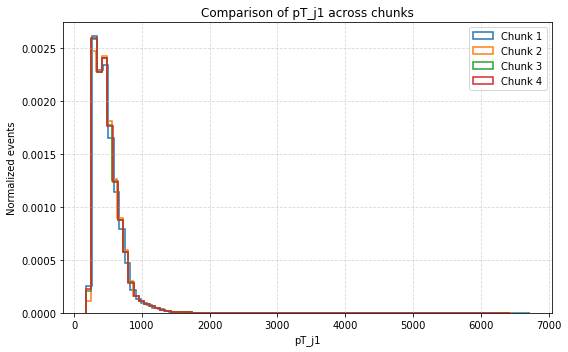

eta_j1: chunk 0 vs 1 → KS=0.000, p=0.520
eta_j1: chunk 0 vs 2 → KS=0.000, p=0.343
eta_j1: chunk 0 vs 3 → KS=0.000, p=0.500
eta_j1: chunk 0 vs 4 → KS=0.000, p=0.868


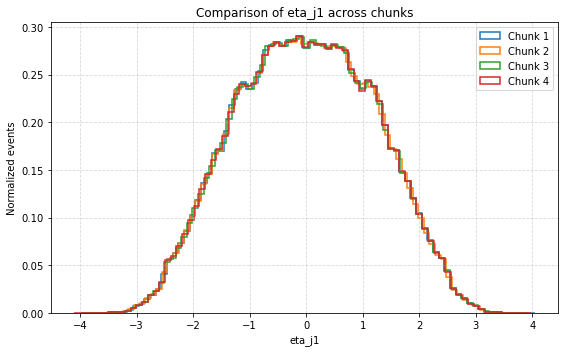

phi_j1: chunk 0 vs 1 → KS=0.001, p=0.063
phi_j1: chunk 0 vs 2 → KS=0.000, p=0.793
phi_j1: chunk 0 vs 3 → KS=0.000, p=0.171
phi_j1: chunk 0 vs 4 → KS=0.000, p=0.850


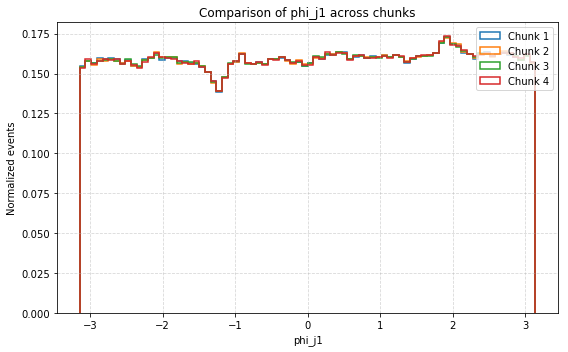

pT_j2: chunk 0 vs 1 → KS=0.000, p=0.239
pT_j2: chunk 0 vs 2 → KS=0.000, p=0.803
pT_j2: chunk 0 vs 3 → KS=0.000, p=0.978
pT_j2: chunk 0 vs 4 → KS=0.000, p=0.807


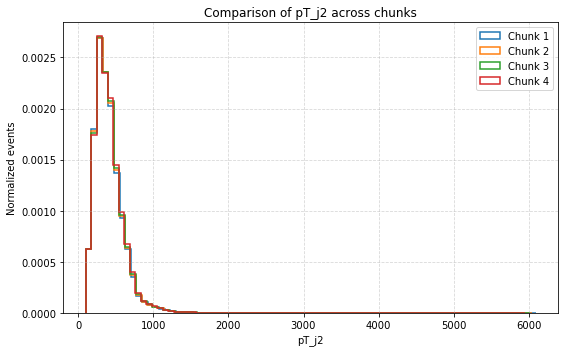

eta_j2: chunk 0 vs 1 → KS=0.000, p=0.550
eta_j2: chunk 0 vs 2 → KS=0.000, p=0.207
eta_j2: chunk 0 vs 3 → KS=0.000, p=0.681
eta_j2: chunk 0 vs 4 → KS=0.001, p=0.121


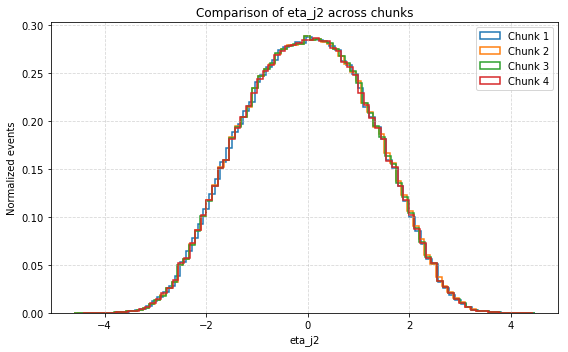

phi_j2: chunk 0 vs 1 → KS=0.001, p=0.102
phi_j2: chunk 0 vs 2 → KS=0.000, p=0.944
phi_j2: chunk 0 vs 3 → KS=0.000, p=0.569
phi_j2: chunk 0 vs 4 → KS=0.001, p=0.208


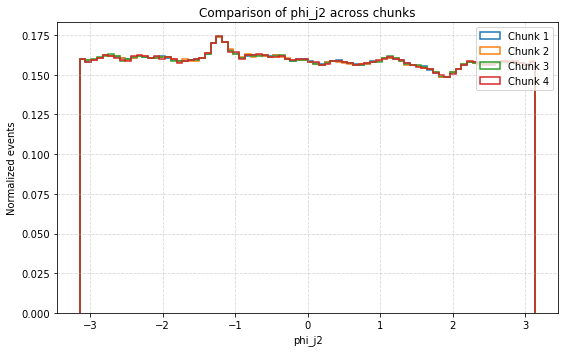

m_jj: chunk 0 vs 1 → KS=0.000, p=0.289
m_jj: chunk 0 vs 2 → KS=0.001, p=0.121
m_jj: chunk 0 vs 3 → KS=0.000, p=0.517
m_jj: chunk 0 vs 4 → KS=0.000, p=0.525


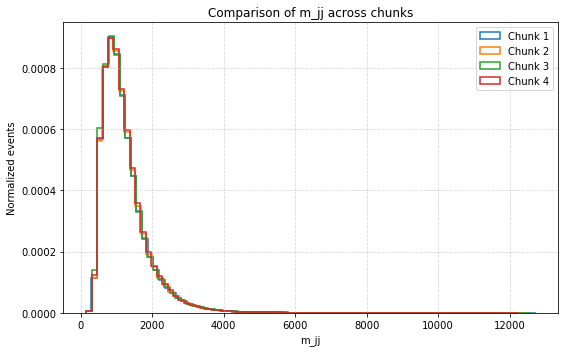

tau21_j1: chunk 0 vs 1 → KS=0.000, p=0.534
tau21_j1: chunk 0 vs 2 → KS=0.000, p=0.946
tau21_j1: chunk 0 vs 3 → KS=0.000, p=0.519
tau21_j1: chunk 0 vs 4 → KS=0.001, p=0.131


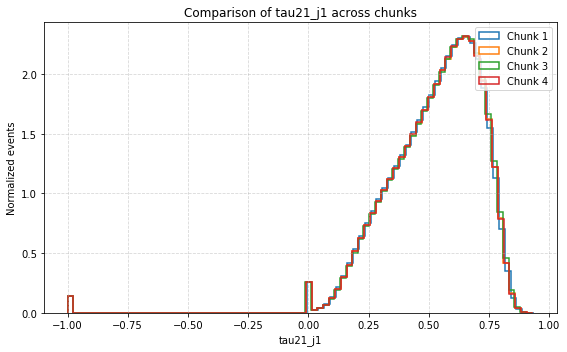

tau21_j2: chunk 0 vs 1 → KS=0.001, p=0.147
tau21_j2: chunk 0 vs 2 → KS=0.000, p=0.760
tau21_j2: chunk 0 vs 3 → KS=0.000, p=0.793
tau21_j2: chunk 0 vs 4 → KS=0.000, p=0.560


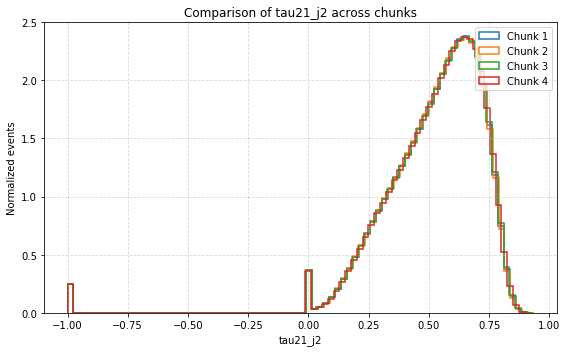

tau32_j1: chunk 0 vs 1 → KS=0.000, p=0.837
tau32_j1: chunk 0 vs 2 → KS=0.000, p=0.260
tau32_j1: chunk 0 vs 3 → KS=0.000, p=0.360
tau32_j1: chunk 0 vs 4 → KS=0.000, p=0.492


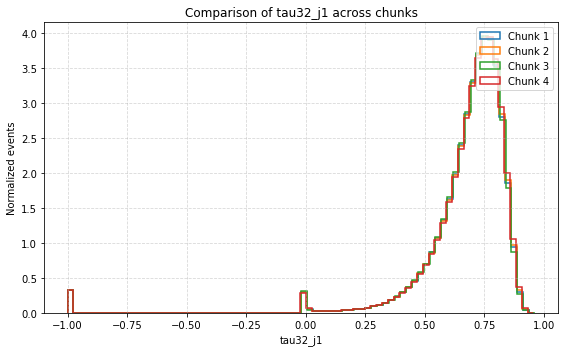

tau32_j2: chunk 0 vs 1 → KS=0.000, p=0.222
tau32_j2: chunk 0 vs 2 → KS=0.000, p=0.660
tau32_j2: chunk 0 vs 3 → KS=0.000, p=0.358
tau32_j2: chunk 0 vs 4 → KS=0.000, p=0.784


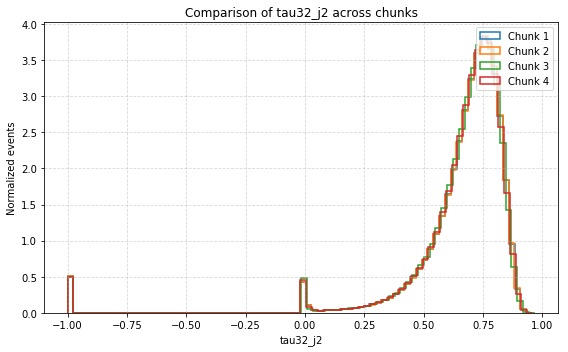

met: chunk 0 vs 1 → KS=0.000, p=0.688
met: chunk 0 vs 2 → KS=0.000, p=0.761
met: chunk 0 vs 3 → KS=0.000, p=0.608
met: chunk 0 vs 4 → KS=0.001, p=0.083


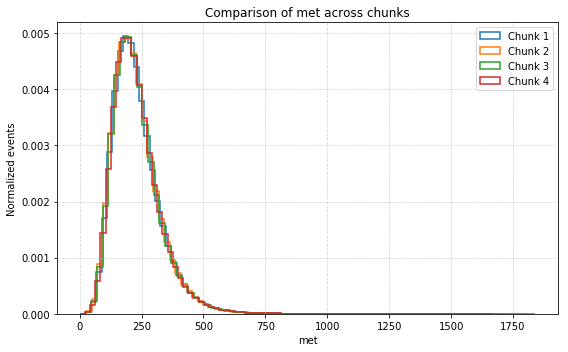

phi_met: chunk 0 vs 1 → KS=0.000, p=0.444
phi_met: chunk 0 vs 2 → KS=0.000, p=0.908
phi_met: chunk 0 vs 3 → KS=0.001, p=0.137
phi_met: chunk 0 vs 4 → KS=0.000, p=0.458


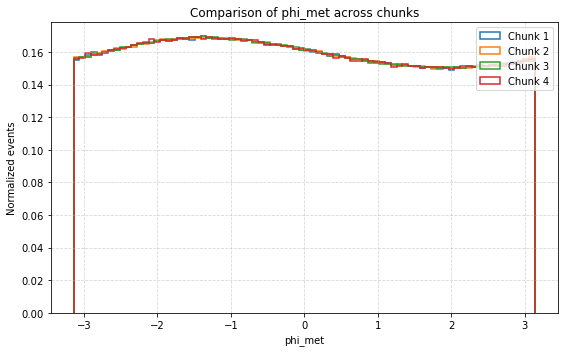

min_dPhi: chunk 0 vs 1 → KS=0.000, p=0.326
min_dPhi: chunk 0 vs 2 → KS=0.000, p=0.315
min_dPhi: chunk 0 vs 3 → KS=0.000, p=0.322
min_dPhi: chunk 0 vs 4 → KS=0.001, p=0.043


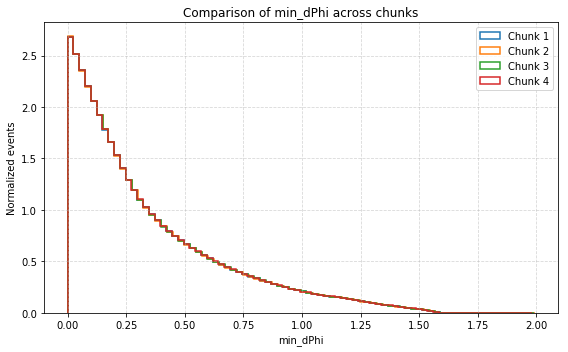

ht: chunk 0 vs 1 → KS=0.000, p=0.949
ht: chunk 0 vs 2 → KS=0.000, p=0.718
ht: chunk 0 vs 3 → KS=0.000, p=0.961
ht: chunk 0 vs 4 → KS=0.000, p=0.361


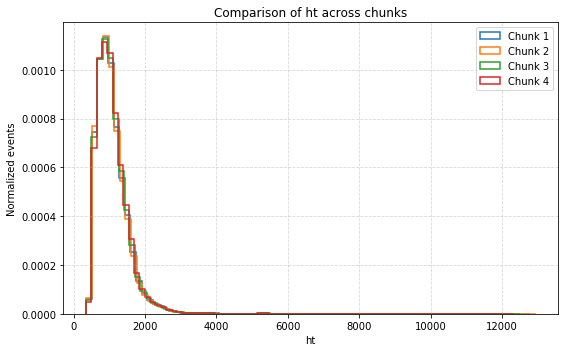

In [13]:
variables = [
    'pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2',
    'm_jj', 'tau21_j1', 'tau21_j2', 'tau32_j1', 'tau32_j2',
    'met', 'phi_met', 'min_dPhi', 'ht'
]

# loop through all variables


for var in variables:
    plt.figure(figsize=(8,5))
    base = mc_chunks[0][var]    
    for i in mc_chunks:
        # if i == 0: continue
        stat, pval = ks_2samp(base, mc_chunks[i][var])
        print(f"{var}: chunk 0 vs {i} → KS={stat:.3f}, p={pval:.3f}")
        data = mc_chunks[i][var]
        plt.hist(
            data, bins=80, histtype='step',
            linewidth=1.5, label=f'Chunk {i}', density=True
        )
    
    plt.xlabel(var)
    plt.ylabel('Normalized events')
    plt.title(f'Comparison of {var} across chunks')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
